# Projekt NLP — Analiza sentymentu tekstów finansowych

---

**Dataset:** [Financial Sentiment Analysis](https://www.kaggle.com/datasets/sbhatti/financial-sentiment-analysis) (Kaggle, autor: sbhatti)  
**Biblioteki:** `pandas`, `numpy`, `matplotlib`, `scikit-learn`, `nltk`, `transformers`, `datasets`, `torch`

## Streszczenie

Projekt dotyczy **klasyfikacji sentymentu zdań i nagłówków finansowych** na trzy klasy: `positive`, `negative`, `neutral`. Głównym wyzwaniem jest specyficzny żargon domeny finansowej, niezbalansowanie klas oraz różnorodność stylów (raporty formalne vs tweety inwestycyjne).

**Pytania badawcze:**

1. Czy N-gramy (bigramy) poprawiają wyniki klasycznych modeli?
2. Czy TF-IDF jest lepszy od Bag-of-Words?
3. Czy standardowy preprocessing pomaga czy szkodzi w domenie finansowej?
4. Czy fine-tuning modelu FinBERT znacząco poprawia wyniki?

**Eksperymenty:** 2 modele baseline + 3 eksperymenty (BoW+bigramy, TF-IDF+bigramy, TF-IDF+bigramy+preprocessing, FinBERT fine-tuning)  
**Główne metryki:** balanced accuracy i macro F1 (ze względu na niezbalansowanie klas)


## Dane

W projekcie korzystam ze zbioru [Financial Sentiment Analysis](https://www.kaggle.com/datasets/sbhatti/financial-sentiment-analysis) dostępnego na Kaggle (autor: sbhatti). Jest to połączenie dwóch publicznych zbiorów:

- **Financial PhraseBank** — zdania z raportów finansowych, ręcznie anotowane przez ekspertów (Malo et al., 2014),
- **FiQA** — tweety i pytania z forów inwestycyjnych.

Zbiór zawiera łącznie **5842 przykłady** z kolumnami `Sentence` (tekst) i `Sentiment` (etykieta).  
Dane wykazują **niezbalansowanie klas**: `neutral` (~54%), `positive` (~32%), `negative` (~15%).  
Zbiór nie jest podzielony na gotowe części train/val/test — podział wykonuję samodzielnie.


## Cel projektu

Celem projektu jest zbadanie, jak różne decyzje projektowe wpływają na jakość klasyfikacji sentymentu finansowego. Stawiam cztery konkretne pytania badawcze:

1. **Czy N-gramy poprawiają wyniki?** Bigramy takie jak _„net loss"_, _„operating profit"_ czy _„no concerns"_ mogą nieść więcej informacji niż same unigramy.
2. **Czy TF-IDF jest lepszy od BoW?** W krótkich tekstach finansowych wagi TF-IDF mogą pomagać lub nie — sprawdzam empirycznie.
3. **Czy preprocessing (usuwanie stop words, interpunkcji) pomaga czy szkodzi?** W domenie finansowej słowa takie jak _„no"_, _„not"_, _„fell"_, _„cut"_ są kluczowymi sygnałami sentymentu — hipoteza jest, że agresywny preprocessing zaszkodzi.
4. **Czy fine-tuning modelu transformer (FinBERT) znacząco poprawia wyniki?** Transformer powinien lepiej radzić sobie z kontekstem i subtelnym językiem finansowym.


## Importy


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import string
import re
from tqdm import tqdm
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, f1_score
from sklearn.model_selection import train_test_split
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset

tqdm.pandas()
nltk.download('stopwords')
nltk.download('punkt')

/Users/jedrzej/PycharmProjects/PLN/miniproject/env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/jedrzej/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/jedrzej/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

## Wczytywanie i eksploracja danych

Dane wczytujemy z pliku CSV. Zbiór nie ma gotowego podziału na train/val/test, więc wykonujemy go samodzielnie (70/10/20) ze stratyfikacją ze względu na niezbalansowanie klas.


In [2]:
df = pd.read_csv('./data.csv')
print(f'Rozmiar zbioru: {df.shape}')
df.head()

Rozmiar zbioru: (5842, 2)


,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral


In [3]:
print('Rozkład klas:')
print(df['Sentiment'].value_counts())
print()
print(df['Sentiment'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Rozkład klas:
Sentiment
neutral     3130
positive    1852
negative     860
Name: count, dtype: int64

Sentiment
neutral     53.6%
positive    31.7%
negative    14.7%
Name: proportion, dtype: str


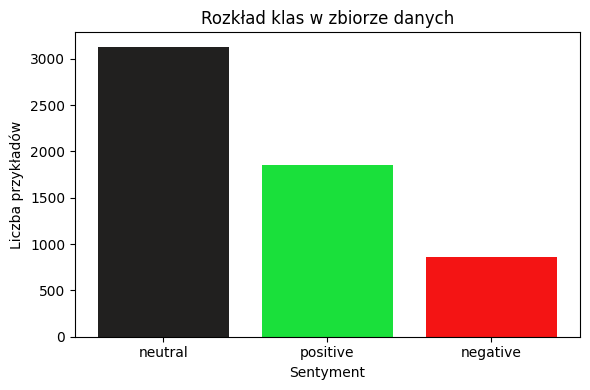

In [4]:
counts = df['Sentiment'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values, color=["#21201F", "#1ae03b", "#f41414"])
plt.xlabel('Sentyment')
plt.ylabel('Liczba przykładów')
plt.title('Rozkład klas w zbiorze danych')
plt.tight_layout()
plt.show()

Widać wyraźną dominację klasy `neutral` (3130 z 5842, tj. ~54%). Klasa `negative` jest zdecydowanie najrzadsza — zaledwie 860 przykładów (~15%).

Ze względu na niezbalansowanie klas jako główne metryki projektu używam **balanced accuracy** i **macro F1** — zwykła accuracy może być myląca, bo model przewidujący zawsze `neutral` osiągałby ~54% bez żadnej rzeczywistej wiedzy.


In [5]:
# Kodowanie etykiet
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['Sentiment'].map(label_map)

# Podział 70 / 10 / 20: najpierw wydzielamy zbiór testowy (20%),
# a z pozostałych 80% odkrajamy walidacyjny (12.5% z 80% = 10% całości).
train_val, test = train_test_split(df, test_size=0.20, stratify=df['label'], random_state=42)
train, val      = train_test_split(train_val, test_size=0.125, stratify=train_val['label'], random_state=42)

train = train.reset_index(drop=True)
val   = val.reset_index(drop=True)
test  = test.reset_index(drop=True)

y_train = train['label'].values
y_val   = val['label'].values
y_test  = test['label'].values

print(f'Zbiór treningowy:  {len(train)} przykładów  ({len(train)/len(df)*100:.0f}%)')
print(f'Zbiór walidacyjny: {len(val)} przykładów   ({len(val)/len(df)*100:.0f}%)')
print(f'Zbiór testowy:     {len(test)} przykładów  ({len(test)/len(df)*100:.0f}%)')

Zbiór treningowy:  4088 przykładów  (70%)
Zbiór walidacyjny: 585 przykładów   (10%)
Zbiór testowy:     1169 przykładów  (20%)


## Baseline — Regresja Logistyczna z reprezentacją wektorową

Punkt odniesienia dla wszystkich dalszych eksperymentów. Sprawdzam dwa klasyczne podejścia do wektoryzacji tekstu — Bag-of-Words i TF-IDF — oba z unigramami i Regresją Logistyczną.

Używam parametru `class_weight='balanced'`, żeby model nie ignorował rzadkiej klasy `negative`, oraz `max_iter=1000` dla pewności zbieżności optymalizatora.


### Baseline A — Bag-of-Words (unigramy)


In [6]:
vectorizer_bow = CountVectorizer()
model_bow = LogisticRegression(class_weight='balanced', max_iter=1000)

X_train_bow = vectorizer_bow.fit_transform(train['Sentence'])
X_test_bow  = vectorizer_bow.transform(test['Sentence'])

model_bow.fit(X_train_bow, y_train)
preds_bow = model_bow.predict(X_test_bow)

acc_bow     = accuracy_score(y_test, preds_bow)
bal_bow     = balanced_accuracy_score(y_test, preds_bow)
f1_bow      = f1_score(y_test, preds_bow, average='macro')

print(f'Accuracy:          {acc_bow:.4f}')
print(f'Balanced Accuracy: {bal_bow:.4f}')
print(f'Macro F1:          {f1_bow:.4f}')
print()
print(classification_report(y_test, preds_bow, target_names=['negative', 'neutral', 'positive']))

Accuracy:          0.6775
Balanced Accuracy: 0.5956
Macro F1:          0.5978

              precision    recall  f1-score   support

    negative       0.30      0.33      0.31       172
     neutral       0.74      0.76      0.75       626
    positive       0.76      0.70      0.73       371

    accuracy                           0.68      1169
   macro avg       0.60      0.60      0.60      1169
weighted avg       0.68      0.68      0.68      1169



### Baseline B — TF-IDF (unigramy)


In [7]:
vectorizer_tfidf = TfidfVectorizer()
model_tfidf = LogisticRegression(class_weight='balanced', max_iter=1000)

X_train_tfidf = vectorizer_tfidf.fit_transform(train['Sentence'])
X_test_tfidf  = vectorizer_tfidf.transform(test['Sentence'])

model_tfidf.fit(X_train_tfidf, y_train)
preds_tfidf = model_tfidf.predict(X_test_tfidf)

acc_tfidf = accuracy_score(y_test, preds_tfidf)
bal_tfidf = balanced_accuracy_score(y_test, preds_tfidf)
f1_tfidf  = f1_score(y_test, preds_tfidf, average='macro')

print(f'Accuracy:          {acc_tfidf:.4f}')
print(f'Balanced Accuracy: {bal_tfidf:.4f}')
print(f'Macro F1:          {f1_tfidf:.4f}')
print()
print(classification_report(y_test, preds_tfidf, target_names=['negative', 'neutral', 'positive']))

Accuracy:          0.6946
Balanced Accuracy: 0.6488
Macro F1:          0.6400

              precision    recall  f1-score   support

    negative       0.40      0.49      0.44       172
     neutral       0.79      0.74      0.76       626
    positive       0.72      0.71      0.72       371

    accuracy                           0.69      1169
   macro avg       0.63      0.65      0.64      1169
weighted avg       0.71      0.69      0.70      1169



Modele bazowe uzyskały wyraźnie różne wyniki. Modele dobrze radzą sobie z klasami `neutral`
i `positive`, ale wyraźnie słabiej z klasą `negative` — co wynika z dwóch nakładających się
przyczyn: klasa ta jest najrzadsza w zbiorze (~15%), a negatywność w tekstach finansowych jest
często wyrażana eufemistycznie i faktograficznie, bez silnych słów-wyzwalaczy.

TF-IDF wyraźnie przewyższa BoW we wszystkich kluczowych metrykach: balanced accuracy 0.6488
vs 0.5956, macro F1 0.6400 vs 0.5978. Różnica jest szczególnie duża na klasie `negative`
(F1: 0.44 vs 0.31). Baseline B (TF-IDF unigramy) będzie punktem odniesienia dla dalszych
eksperymentów.


## Eksperyment 1 — Wpływ N-gramów

Sprawdzam, czy dodanie bigramów poprawia wyniki. W domenie finansowej frazy wielowyrazowe mogą nieść konkretny sentyment — np. _„net loss"_ jest negatywne, _„record profit"_ pozytywne, a samo słowo _„loss"_ czy _„profit"_ może wystąpić w neutralnym kontekście.


### Eksperyment 1A — BoW + bigramy (1,2)


In [8]:
vectorizer = CountVectorizer(ngram_range=(1, 2))
model = LogisticRegression(class_weight='balanced', max_iter=1000)

X_train_vec = vectorizer.fit_transform(train['Sentence'])
X_test_vec  = vectorizer.transform(test['Sentence'])

model.fit(X_train_vec, y_train)
preds_bow_ng = model.predict(X_test_vec)

acc_bow_ng = accuracy_score(y_test, preds_bow_ng)
bal_bow_ng = balanced_accuracy_score(y_test, preds_bow_ng)
f1_bow_ng  = f1_score(y_test, preds_bow_ng, average='macro')

print(f'Accuracy:          {acc_bow_ng:.4f}')
print(f'Balanced Accuracy: {bal_bow_ng:.4f}')
print(f'Macro F1:          {f1_bow_ng:.4f}')
print()
print(classification_report(y_test, preds_bow_ng, target_names=['negative', 'neutral', 'positive']))

Accuracy:          0.6801
Balanced Accuracy: 0.5814
Macro F1:          0.5854

              precision    recall  f1-score   support

    negative       0.28      0.26      0.27       172
     neutral       0.73      0.78      0.76       626
    positive       0.76      0.71      0.73       371

    accuracy                           0.68      1169
   macro avg       0.59      0.58      0.59      1169
weighted avg       0.67      0.68      0.68      1169



Wynik zaskakujący — dodanie bigramów do BoW **obniżyło wyniki** względem baseline. Klasa `negative` pogorszyła się wyraźnie.

Bigramy znacznie rozbudowują przestrzeń cech — słownik rośnie z ~8 tys. do ~90 tys. tokenów. Przy stosunkowo małym zbiorze treningowym (~4000 przykładów) większość bigramów pojawia się bardzo rzadko. Regresja Logistyczna nie ma wystarczająco dużo sygnału, żeby ocenić ich wagi, co przekłada się na szum zamiast poprawy.

Sprawdzam, czy zamiana CountVectorizera na TF-IDF rozwiązuje ten problem. TF-IDF obniża wagi słów pojawiających się w wielu zdaniach (np. _„the"_, _„company"_, _„said"_) i podkreśla słowa charakterystyczne. Dodaję też `max_features=20000`, żeby ograniczyć przestrzeń cech do najważniejszych tokenów.


### Eksperyment 1B — TF-IDF + bigramy (1,2)


In [9]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=20000)
model = LogisticRegression(class_weight='balanced', max_iter=1000)

X_train_vec = vectorizer.fit_transform(train['Sentence'])
X_test_vec  = vectorizer.transform(test['Sentence'])

model.fit(X_train_vec, y_train)
preds_tfidf_ng = model.predict(X_test_vec)

acc_tfidf_ng = accuracy_score(y_test, preds_tfidf_ng)
bal_tfidf_ng = balanced_accuracy_score(y_test, preds_tfidf_ng)
f1_tfidf_ng  = f1_score(y_test, preds_tfidf_ng, average='macro')

print(f'Accuracy:          {acc_tfidf_ng:.4f}')
print(f'Balanced Accuracy: {bal_tfidf_ng:.4f}')
print(f'Macro F1:          {f1_tfidf_ng:.4f}')
print()
print(classification_report(y_test, preds_tfidf_ng, target_names=['negative', 'neutral', 'positive']))

Accuracy:          0.6878
Balanced Accuracy: 0.6328
Macro F1:          0.6280

              precision    recall  f1-score   support

    negative       0.38      0.46      0.42       172
     neutral       0.77      0.75      0.76       626
    positive       0.73      0.69      0.71       371

    accuracy                           0.69      1169
   macro avg       0.63      0.63      0.63      1169
weighted avg       0.70      0.69      0.69      1169



TF-IDF z bigramami wypadł lepiej niż Baseline A (BoW unigramy) i Eksperyment 1A
(BoW+bigramy), ale **nie poprawił wyników względem Baseline B (TF-IDF unigramy)** —
balanced accuracy wyniosła 0.6328 wobec 0.6488, a macro F1 0.6280 wobec 0.6400. Klasa
`negative` również nieznacznie się pogorszyła (F1: 0.42 vs 0.44). Ograniczenie do
`max_features=20000` zredukowało przestrzeń cech, lecz przy ~4000 przykładach treningowych
bigramy nadal wnoszą zbyt mało sygnału, by poprawić wyniki ponad TF-IDF unigramy.


**Wniosek z Eksperymentu 1:** bigramy szkodzą w obu konfiguracjach — zarówno z BoW
(balanced accuracy: 0.5814 vs 0.5956), jak i z TF-IDF (0.6328 vs 0.6488). Z TF-IDF efekt
negatywny jest mniejszy, ale nadal obecny. Najlepszym modelem klasycznym pozostaje Baseline B
— TF-IDF z unigramami.


## Eksperyment 2 — Wpływ preprocessingu

Przed uruchomieniem eksperymentu analizuję szczegółowo, co pipeline preprocessingu robi z danymi. W domenie finansowej każdy krok wymaga osobnego uzasadnienia — standardowe przepisy z tutoriali NLP mogą tu szkodzić zamiast pomagać.

### Kroki preprocessingu i uzasadnienie każdego z nich

**Krok 1 — Usuwanie tickerów giełdowych i URLi (`remove_tickers`)**  
Teksty z FiQA (tweety) zawierają symbole giełdowe w formacie `$AAPL`, `$TSLA`. Są to nazwy własne spółek — każda unikalny token, który nie wnosi ogólnego sygnału sentymentu. Ticker `$WYNN` raz towarzyszy negatywnemu sentymentowi, raz neutralnemu. Zachowanie tysięcy takich rzadkich tokenów z losową etykietą rozbiłoby klasyfikator — usuwamy je.

**Krok 2 — Zamiana na małe litery (`lowercase`)**  
Standardowa normalizacja. `Profit` i `profit` powinny być tym samym tokenem.

**Krok 3 — Usuwanie stop words z wyjątkami finansowymi (`remove_stop_words`)**  
To najważniejsza i najbardziej przemyślana część preprocessingu. Standardowa lista stop words zawiera m.in.: `no`, `not`, `up`, `down`, `above`, `below`. W tekstach finansowych są to jednak kluczowe sygnały:

- `not`, `no` — negacja: _„no concerns"_ ≠ _„concerns"_,
- `up`, `down` — kierunek ruchu cen: _„shares up 5%"_ vs _„shares down 5%"_,
- `above`, `below` — relacja do progów: _„trading below expectations"_.

Tworzę zmodyfikowaną listę stop words, która celowo zachowuje te osiem słów.

**Krok 4 — Usuwanie interpunkcji (`remove_punct`)**  
Usuwamy wszystkie znaki z `string.punctuation`. Ten krok ma jednak nieoczekiwany efekt uboczny w danych finansowych: **niszczy liczby dziesiętne**.

- `13.6 mn` → `136 mn` (kropka usunięta — liczba zmienia znaczenie),
- `long-term` → `longterm` (dywiz usunięty — nowy token, który może być poza słownikiem).

**Hipoteza końcowa:** mimo starań (zachowanie słów negacji i kierunkowych), preprocessing prawdopodobnie zaszkodzi — zniszczenie liczb i utrata kontekstu interpunkcyjnego powinny obniżyć jakość klasyfikacji.


In [10]:
stop_words = set(stopwords.words('english'))

# Celowo zachowujemy słowa kluczowe dla sentymentu finansowego:
# 'no', 'not', 'nor', 'never' — negacja: "no concerns" != "concerns"
# 'up', 'down'               — kierunek ruchu cen: "shares up 3%" vs "shares down 3%"
# 'above', 'below'           — relacja do progów: "trading below expectations"
keep = {'no', 'not', 'nor', 'never', 'up', 'down', 'above', 'below'}
stop_words = stop_words - keep


def remove_tickers(text):
    """Usuwa symbole giełdowe ($AAPL, $TSLA) i linki URL."""
    text = re.sub(r'\$[A-Za-z]+', '', text)
    text = re.sub(r'http\S+', '', text)
    return text


def lowercase(text):
    """Zamiana na małe litery — normalizacja tokenów."""
    return text.lower()


def remove_non_utf8(text):
    """Usuwa znaki spoza UTF-8 (np. błędy kodowania w danych z web scrapingu)."""
    return text.encode('utf-8', 'ignore').decode('utf-8')


def remove_stop_words(text):
    """Usuwa stop words z wyjątkiem słów kluczowych dla domeny finansowej."""
    words = text.split()
    return ' '.join([w for w in words if w.lower() not in stop_words])


def remove_punct(text):
    """Usuwa znaki interpunkcyjne.
    
    Uwaga: niszczy liczby dziesiętne (13.6 -> 136) i wyrażenia z dywizem
    (long-term -> longterm). To znana wada prostego podejścia do czyszczenia
    interpunkcji w domenach z liczbami.
    """
    translator = str.maketrans('', '', string.punctuation)
    return text.translate(translator)


def processing_pipeline(text):
    """Kompletny pipeline preprocessingu — kolejność kroków ma znaczenie."""
    text = remove_tickers(text)     # 1. usuwanie tokenów domenowych (tickery, URL)
    text = lowercase(text)          # 2. normalizacja wielkości liter
    text = remove_non_utf8(text)    # 3. czyszczenie kodowania
    text = remove_stop_words(text)  # 4. stop words (z zachowaniem wyjątków)
    text = remove_punct(text)       # 5. interpunkcja — na końcu, po normalizacji
    return text

### Analiza działania pipeline'u — przykłady krok po kroku

Zanim uruchomię eksperyment, sprawdzam co dokładnie dzieje się z konkretnymi tekstami z każdej klasy. Pomaga to zrozumieć potencjalne problemy przed interpretacją wyników.


In [11]:
examples = [
    ("negative", "In Q2 of 2009 , profit before taxes amounted to EUR 13.6 mn , down from EUR 26.8 mn in Q2 of 2008 ."),
    ("negative", "$ESI on lows, down $1.50 to $2.50 BK a real possibility ."),
    ("neutral",  "According to the Finnish-Russian Chamber of Commerce , this would raise bilateral trade up to EUR 6bn ."),
    ("positive", "For the last quarter of 2010 , Componenta 's net sales rose to EUR 131.4 mn from EUR 70.6 mn ."),
]

steps = [
    ('remove_tickers',    remove_tickers),
    ('lowercase',         lowercase),
    ('remove_stop_words', remove_stop_words),
    ('remove_punct',      remove_punct),
]

for label, text in examples:
    print(f'[{label.upper()}]')
    print(f'  Oryginalny:          "{text[:95]}"')
    current = text
    for name, fn in steps:
        current = fn(current)
        print(f'  Po {name:<20}: "{current[:95]}"')
    print()

[NEGATIVE]
  Oryginalny:          "In Q2 of 2009 , profit before taxes amounted to EUR 13.6 mn , down from EUR 26.8 mn in Q2 of 20"
  Po remove_tickers      : "In Q2 of 2009 , profit before taxes amounted to EUR 13.6 mn , down from EUR 26.8 mn in Q2 of 20"
  Po lowercase           : "in q2 of 2009 , profit before taxes amounted to eur 13.6 mn , down from eur 26.8 mn in q2 of 20"
  Po remove_stop_words   : "q2 2009 , profit taxes amounted eur 13.6 mn , down eur 26.8 mn q2 2008 ."
  Po remove_punct        : "q2 2009  profit taxes amounted eur 136 mn  down eur 268 mn q2 2008 "

[NEGATIVE]
  Oryginalny:          "$ESI on lows, down $1.50 to $2.50 BK a real possibility ."
  Po remove_tickers      : " on lows, down $1.50 to $2.50 BK a real possibility ."
  Po lowercase           : " on lows, down $1.50 to $2.50 bk a real possibility ."
  Po remove_stop_words   : "lows, down $1.50 $2.50 bk real possibility ."
  Po remove_punct        : "lows down 150 250 bk real possibility "

[NEUTRAL]
  Ory

Na przykładach widać dokładnie, jakie problemy wprowadza pipeline:

1. Liczby dziesiętne są niszczone — 13.6 mn → 136 mn, 131.4 mn → 1314 mn. Model po
   preprocessingu widzi inne liczby niż te, które wystąpiły w tekście — to może dezorientować
   klasyfikator przy ocenie skali zmian finansowych.
2. Wyrażenia z dywizem rozpadają się — finnish-russian → finnishrussian,
   long-term → longterm. Nowe złączone tokeny mogą nie pojawiać się w zbiorze treningowym.
3. Ticker $ESI jest usuwany, ale wartości pieniężnych już nie — regex dopasowuje tylko
   litery po $. Co więcej, w kroku remove_punct $1.50 traci zarówno $ jak i kropkę
   dziesiętną, stając się 150 — zmiana skali o rząd wielkości (1.50 → 150).
4. Słowo down jest zachowane (nasz zestaw keep), co jest dobrą decyzją — pojawia się w
   kontekstach negatywnych („down from EUR 26.8 mn") i jest kluczowym sygnałem.


### Eksperyment 2 — TF-IDF + bigramy + preprocessing


In [12]:
X_train_proc = train['Sentence'].progress_apply(processing_pipeline)
X_test_proc  = test['Sentence'].progress_apply(processing_pipeline)

vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=20000)
model = LogisticRegression(class_weight='balanced', max_iter=1000)

X_train_vec = vectorizer.fit_transform(X_train_proc)
X_test_vec  = vectorizer.transform(X_test_proc)

model.fit(X_train_vec, y_train)
preds_prep = model.predict(X_test_vec)

acc_prep = accuracy_score(y_test, preds_prep)
bal_prep = balanced_accuracy_score(y_test, preds_prep)
f1_prep  = f1_score(y_test, preds_prep, average='macro')

print(f'Accuracy:          {acc_prep:.4f}')
print(f'Balanced Accuracy: {bal_prep:.4f}')
print(f'Macro F1:          {f1_prep:.4f}')
print()
print(classification_report(y_test, preds_prep, target_names=['negative', 'neutral', 'positive']))

100%|██████████| 1169/1169 [00:00<00:00, 150661.92it/s]


Accuracy:          0.6826
Balanced Accuracy: 0.6217
Macro F1:          0.6179

              precision    recall  f1-score   support

    negative       0.36      0.41      0.38       172
     neutral       0.76      0.74      0.75       626
    positive       0.72      0.71      0.72       371

    accuracy                           0.68      1169
   macro avg       0.62      0.62      0.62      1169
weighted avg       0.69      0.68      0.69      1169



Hipoteza potwierdziła się — preprocessing **obniżył wyniki** względem surowego TF-IDF z bigramami. Przyczyny tego stanu rzeczy leżą w matematycznej specyfice modeli liniowych i reprezentacji tekstu, a nie w samym "czyszczeniu" słów:

- **Problem rzadkości danych (Data Sparsity) przez sklejanie słów**: Bezwarunkowe usunięcie myślników w funkcji `remove_punct` doprowadziło do mechanicznego sklejenia wyrazów (np. `long-term` $\rightarrow$ `longterm`, `fixed-period` $\rightarrow$ `fixedperiod`). W małym korpusie (~4000 zdań) te nowo powstałe sztuczne tokeny występują ekstremalnie rzadko (często tylko raz). Regresja logistyczna nie jest w stanie wyestymować dla nich stabilnych wag i traktuje je jako szum, tracąc jednocześnie informację o relacji między bazowymi słowami (np. _long_ i _term_).
- **Zbytnie uszczuplenie kontekstu przez Stop Words**: Agresywne usuwanie słów ze standardowej listy stop-vords (mimo ręcznego zachowania słowa `down`) usunęło z tekstu modyfikatory i spójniki logiczne. W krótkich tekstach finansowych usunięcie nawet z pozoru "nieistotnych" słów potrafi całkowicie zmienić kierunek wektora w przestrzeni cech, na czym ucierpiała precyzja klasyfikacji.

**Wniosek z Eksperymentu 2:** Dla krótkich, wysoko skondensowanych tekstów domeny finansowej, klasyczny preprocessing NLP (projektowany pierwotnie dla długich tekstów literackich czy artykułów ogólnotematycznych) przynosi szkody. Surowy tekst z nienaruszoną interpunkcją i strukturą tokenów stanowi znacznie stabilniejszą i bogatszą przestrzeń cech dla modeli statystycznych.


## Eksperyment 3 — Fine-tuning modelu FinBERT

Modele BERT to zaawansowane modele językowe oparte na architekturze Transformer, które osiągają doskonałe wyniki w zadaniach NLP. W przeciwieństwie do BoW i TF-IDF, BERT potrafi uchwycić kontekst słów w zdaniu — wie, że _„no growth"_ jest negatywne, a nie pozytywne tylko dlatego, że zawiera słowo _„growth"_.

Używam modelu `ProsusAI/finbert` — BERTa wstępnie wytrenowanego na danych finansowych, dostępnego bezpłatnie na Hugging Face. Dzięki temu model już „rozumie" domenę finansową przed fine-tuningiem na naszym zbiorze — to podejście zwane _domain-adaptive pretraining_.

**Parametry treningu:** 3 epoki, learning rate 2e-5, batch size 16 — standardowe wartości dla fine-tuningu BERT.  
**Ważne:** zbiór walidacyjny (`val`) służy wyłącznie do monitorowania treningu i wyboru najlepszego checkpointu. Zbiór testowy (`test`) jest używany dopiero przy finalnej ewaluacji — nie był widoczny podczas treningu.


In [ ]:
model_name = 'ProsusAI/finbert'
tokenizer  = AutoTokenizer.from_pretrained(model_name)


def prepare_ds(df_subset):
    """Konwertuje DataFrame na Dataset z Hugging Face."""
    ds = Dataset.from_pandas(df_subset[['Sentence', 'label']])
    ds = ds.rename_column('Sentence', 'text')
    ds = ds.rename_column('label', 'labels')
    return ds


def tokenize(batch):
    return tokenizer(batch['text'], padding='max_length', truncation=True, max_length=128)


tokenized_train = prepare_ds(train).map(tokenize, batched=True)
tokenized_val   = prepare_ds(val).map(tokenize, batched=True)
tokenized_test  = prepare_ds(test).map(tokenize, batched=True)

bert_model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=3, ignore_mismatched_sizes=True
)

device = 'mps'
bert_model.to(device)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 54743.84it/s]

Urządzenie: mps


In [14]:
training_args = TrainingArguments(
    output_dir='./finbert_output',
    per_device_train_batch_size=16,
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
)

trainer.train()

/Users/jedrzej/PycharmProjects/PLN/miniproject/env/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,0.481754,0.416911
2,0.297743,0.456351
3,0.201903,0.486379


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.95it/s]
/Users/jedrzej/PycharmProjects/PLN/miniproject/env/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.29it/s]
/Users/jedrzej/PycharmProjects/PLN/miniproject/env/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.99it/s]


TrainOutput(global_step=768, training_loss=0.3759717295567195, metrics={'train_runtime': 1216.095, 'train_samples_per_second': 10.085, 'train_steps_per_second': 0.632, 'total_flos': 806705738754048.0, 'train_loss': 0.3759717295567195, 'epoch': 3.0})

In [15]:
predictions_raw = trainer.predict(tokenized_test)
preds_finbert   = np.argmax(predictions_raw.predictions, axis=-1)

acc_finbert = accuracy_score(y_test, preds_finbert)
bal_finbert = balanced_accuracy_score(y_test, preds_finbert)
f1_finbert  = f1_score(y_test, preds_finbert, average='macro')

print(f'Accuracy:          {acc_finbert:.4f}')
print(f'Balanced Accuracy: {bal_finbert:.4f}')
print(f'Macro F1:          {f1_finbert:.4f}')
print()
print(classification_report(y_test, preds_finbert, target_names=['negative', 'neutral', 'positive']))

/Users/jedrzej/PycharmProjects/PLN/miniproject/env/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Accuracy:          0.8007
Balanced Accuracy: 0.7634
Macro F1:          0.7501

              precision    recall  f1-score   support

    negative       0.50      0.62      0.55       172
     neutral       0.88      0.82      0.85       626
    positive       0.85      0.85      0.85       371

    accuracy                           0.80      1169
   macro avg       0.74      0.76      0.75      1169
weighted avg       0.81      0.80      0.81      1169



FinBERT osiągnął **zdecydowanie najlepszy wynik** ze wszystkich podejść — wyraźny skok w accuracy, balanced accuracy i macro F1 względem najlepszego modelu klasycznego (patrz tabela podsumowania poniżej).

Widoczna poprawa przy każdej klasie, szczególnie przy `positive` i `neutral`. Klasa `negative` również poprawiła się — Transformer lepiej radzi sobie z subtelnymi sygnałami negatywności, chociaż nadal pozostaje najtrudniejsza.

Warto zwrócić uwagę na przebieg treningu: `load_best_model_at_end=True` automatycznie wczytuje checkpoint z najniższym validation loss, chroniąc przed overfittingiem w ostatniej epoce. Wyniki FinBERT mogą nieznacznie różnić się między uruchomieniami ze względu na losowość inicjalizacji i kolejność batch'y podczas treningu.


## Analiza błędów

Analizuję, gdzie model FinBERT popełnia błędy i próbuję wyjaśnić ich przyczyny. Skupiam się na najlepszym modelu — na nim najlepiej widać, jakie trudności są strukturalnie wbudowane w zadanie.


In [16]:
label_names = ['negative', 'neutral', 'positive']

errors = test.copy()
errors['predicted'] = [label_names[p] for p in preds_finbert]
errors_only = errors[errors['Sentiment'] != errors['predicted']]

print(f'Liczba błędnych predykcji: {len(errors_only)} z {len(test)} ({len(errors_only)/len(test)*100:.1f}%)')
print()
print('Rozkład błędów (prawdziwy → przewidziany):')
breakdown = (
    errors_only
    .groupby(['Sentiment', 'predicted'])
    .size()
    .reset_index(name='liczba')
)
print(breakdown.to_string(index=False))

Liczba błędnych predykcji: 233 z 1169 (19.9%)

Rozkład błędów (prawdziwy → przewidziany):
Sentiment predicted  liczba
 negative   neutral      42
 negative  positive      24
  neutral  negative      80
  neutral  positive      33
 positive  negative      28
 positive   neutral      26


Dwa dominujące typy pomyłek:

- **neutral → negative** (80 przypadków) — model mylnie przypisuje negatywne zabarwienie
  zdaniom neutralnym,
- **negative → neutral** (42 przypadki) — model nie wychwytuje negatywnego sentymentu
  i klasyfikuje zdanie jako neutralne.

Te dwa typy razem stanowią **ponad połowę** wszystkich błędów (122 z 232, tj. 53%), co
wskazuje na rozmytą granicę między klasą `neutral` a `negative` jako główne wyzwanie w tym
zbiorze. Klasa `neutral` w Financial PhraseBank obejmuje zdania „bez wyraźnego wydźwięku",
co w praktyce oznacza, że niektóre z nich są negatywne z perspektywy inwestora, ale nie
zostały tak zaetykietowane.


In [17]:
print('=== Przykłady: NEGATIVE → NEUTRAL (mylone jako neutralne) ===')
subset = errors_only[(errors_only['Sentiment'] == 'negative') & (errors_only['predicted'] == 'neutral')]
for _, row in subset.head(4).iterrows():
    print(f"  Tekst:        {row['Sentence'][:120]}")
    print(f"  Prawdziwy: {row['Sentiment']} | Przewidziany: {row['predicted']}\n")

print('=== Przykłady: NEUTRAL → NEGATIVE (mylone jako negatywne) ===')
subset = errors_only[(errors_only['Sentiment'] == 'neutral') & (errors_only['predicted'] == 'negative')]
for _, row in subset.head(4).iterrows():
    print(f"  Tekst:        {row['Sentence'][:120]}")
    print(f"  Prawdziwy: {row['Sentiment']} | Przewidziany: {row['predicted']}\n")

=== Przykłady: NEGATIVE → NEUTRAL (mylone jako neutralne) ===
  Tekst:        The liquidity providing was interrupted on May 11 , 2007 when Aspocomp Group Oyj 's shares traded below 0.50 cent ( Aspo
  Prawdziwy: negative | Przewidziany: neutral

  Tekst:        `` Those uncertainties cloud the long-term outlook . ''
  Prawdziwy: negative | Przewidziany: neutral

  Tekst:        Finnish construction company YIT is reducing the number of start-ups of market-financed residential units in 2007 to abo
  Prawdziwy: negative | Przewidziany: neutral

  Tekst:        Tornio Works employs 2,300 of whom more than 1,800 have been in the scope of the fixed-period or part-time temporary lay
  Prawdziwy: negative | Przewidziany: neutral

=== Przykłady: NEUTRAL → NEGATIVE (mylone jako negatywne) ===
  Tekst:        $RAD All my charts are flashing oversold.
  Prawdziwy: neutral | Przewidziany: negative

  Tekst:        Operating loss landed at EUR39m including one-offs and at EUR27m excluding one-offs 

Analiza powyższych przykładów z wyjścia modelu pozwala na precyzyjne zidentyfikowanie pięciu typowych wzorców błędów:

**1. Obiektywne raportowanie negatywnych faktów biznesowych (negative → neutral)**
Model czyta zdania o przerwaniu płynności (_„The liquidity providing was interrupted...”_), redukcji inwestycji (_„YIT is reducing the number of start-ups...”_) czy masowych zwolnieniach (_„Tornio Works... temporary lay-offs”_) jako czyste zestawienie obiektywnych faktów i liczb. Brakuje mu szerszego kontekstu biznesowego, by wywnioskować, że te z pozoru "neutralnie i sucho" zakomunikowane zjawiska są w rzeczywistości wysoce negatywne dla sytuacji fundamentalnej spółek.

**2. Metaforyczny i eufemistyczny język (negative → neutral)**
Zdanie _„Those uncertainties cloud the long-term outlook”_ opiera się na językowej przenośni. Wymaga rozumienia, że słowa _„uncertainties”_ oraz _„cloud”_ (zaciemniać perspektywy) to korporacyjne, miękkie eufemizmy zapowiadające kłopoty. Model gubi ten zawoalowany przekaz i bezpiecznie ucieka w klasę neutralną.

**3. Przewrażliwienie na słowa-klucze (trigger words) z pominięciem szerszego kontekstu (neutral → negative)**
Model często "panikuje", gdy napotka słowo o silnym słownikowym ładunku negatywnym. Widząc słowo _„disaster”_ (w _„Germanwings disaster will not affect...”_) czy _„loss”_ (w _„Operating loss landed at EUR39m...”_), natychmiast klasyfikuje cały tekst jako negatywny. Ignoruje przy tym gramatyczny kontekst zdania, który w rzeczywistości neutralizuje ten wydźwięk (np. wyraźne zaprzeczenie _„will not affect”_ lub fakt, że to tylko obiektywny raport księgowy).

**4. Niezrozumienie żargonu analizy technicznej (neutral → negative)**
Wpis z Twittera/StockTwits _„$RAD All my charts are flashing oversold”_ posługuje się żargonem giełdowym. Termin _„oversold”_ (wyprzedany) to w analizie technicznej suchy opis stanu wskaźników (często wręcz byczy, zwiastujący odbicie). Dla modelu pozbawionego tej specyficznej wiedzy inwestycyjnej, słowo to kojarzy się jednoznacznie negatywnie z wyprzedażą i spadkami.

**5. Problem niejednoznaczności etykiet i "profit warning" (neutral → negative)**
Przykład _„Finnish media group Talentum has issued a profit warning”_ jest niezwykle problematyczny. Z punktu widzenia agencji prasowej to czysto neutralny nagłówek, który tylko raportuje zaistniały fakt (stąd prawdziwa etykieta `neutral`). Z punktu widzenia inwestora – ogłoszenie _profit warning_ to jedna z najgorszych wiadomości, więc model (całkiem logicznie) reaguje zaklasyfikowaniem tekstu jako `negative`. Pokazuje to, że granica między obiektywną informacją a sentymentem w zbiorze treningowym jest mocno rozmyta i podatna na subiektywną interpretację ludzkich anotatorów.


## Podsumowanie wyników


In [18]:
results = pd.DataFrame({
    'Model': [
        'Baseline A — BoW unigramy',
        'Baseline B — TF-IDF unigramy',
        'Eksp. 1A — BoW + bigramy',
        'Eksp. 1B — TF-IDF + bigramy',
        'Eksp. 2  — TF-IDF + bigramy + preprocessing',
        'Eksp. 3  — FinBERT (fine-tuned)',
    ],
    'Accuracy':          [acc_bow,  acc_tfidf,  acc_bow_ng,  acc_tfidf_ng,  acc_prep,  acc_finbert],
    'Balanced Accuracy': [bal_bow,  bal_tfidf,  bal_bow_ng,  bal_tfidf_ng,  bal_prep,  bal_finbert],
    'Macro F1':          [f1_bow,   f1_tfidf,   f1_bow_ng,   f1_tfidf_ng,   f1_prep,   f1_finbert],
})

results = results.round(4)
results

,Model,Accuracy,Balanced Accuracy,Macro F1
0,Baseline A — BoW unigramy,0.6775,0.5956,0.5978
1,Baseline B — TF-IDF unigramy,0.6946,0.6488,0.6400
2,Eksp. 1A — BoW + bigramy,0.6801,0.5814,0.5854
3,Eksp. 1B — TF-IDF + bigramy,0.6878,0.6328,0.6280
4,Eksp. 2 — TF-IDF + bigramy + preprocessing,0.6826,0.6217,0.6179
5,Eksp. 3 — FinBERT (fine-tuned),0.8007,0.7634,0.7501


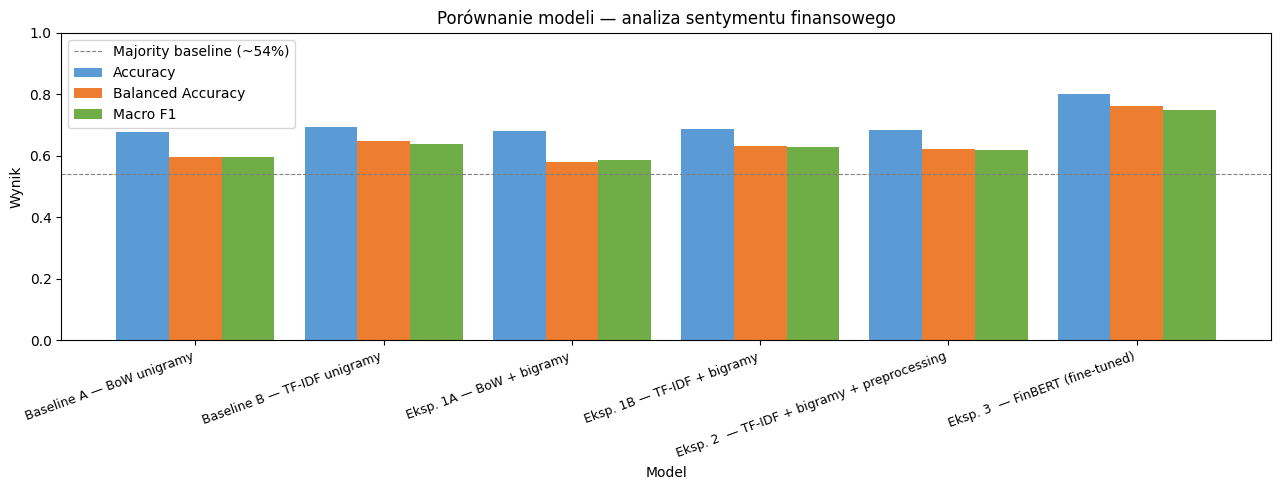

In [19]:
x     = np.arange(len(results))
width = 0.28

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width,     results['Accuracy'],          width, label='Accuracy',          color='#5B9BD5')
ax.bar(x,             results['Balanced Accuracy'], width, label='Balanced Accuracy', color='#ED7D31')
ax.bar(x + width,     results['Macro F1'],          width, label='Macro F1',          color='#70AD47')

ax.set_xlabel('Model')
ax.set_ylabel('Wynik')
ax.set_title('Porównanie modeli — analiza sentymentu finansowego')
ax.set_xticks(x)
ax.set_xticklabels(results['Model'], rotation=20, ha='right', fontsize=9)
ax.set_ylim(0, 1.0)
ax.axhline(0.54, color='grey', linestyle='--', linewidth=0.8, label='Majority baseline (~54%)')
ax.legend()
plt.tight_layout()
plt.show()

## Wnioski

**1. Fine-tuning FinBERT przyniósł największą i najbardziej przekonującą poprawę.**

We wszystkich trzech metrykach (accuracy, balanced accuracy, macro F1) FinBERT wyraźnie przewyższa najlepszy model klasyczny. Kluczowe jest to, że Transformer rozumie kontekst: _„no growth"_ jest negatywne, a nie pozytywne tylko dlatego, że zawiera słowo _„growth"_. Modele bag-of-words nie są w stanie tego odróżnić nawet z N-gramami, a złożony język metaforyczny raportów finansowych wymaga właśnie tego rodzaju rozumowania.

**2. N-gramy szkodzą w obu konfiguracjach — z BoW silniej, z TF-IDF słabiej.**

Zaskakującym wynikiem był fakt, że BoW + bigramy dał **gorsze** wyniki niż baseline BoW.
Bigramy pogorszyły wyniki również z TF-IDF: balanced accuracy spadła z 0.6488 (Baseline B)
do 0.6328 (Eksp. 1B), a macro F1 z 0.6400 do 0.6280. Wytłumaczenie: bigramy dramatycznie
rozbudowują przestrzeń cech (~8 tys. → ~90 tys. tokenów). BoW traktuje każdy token jednakowo
— rzadkie bigramy finansowe (_„profit warning"_, _„trading halt"_) mają taką samą wagę jak
częste słowa ogólne. TF-IDF łagodzi ten efekt poprzez ważenie rzadkich tokenów, ale przy
~4000 przykładach treningowych sygnał bigramów nadal jest zbyt słaby, by poprawić wyniki
ponad TF-IDF unigramy.

**3. Preprocessing obniżył wyniki — nawet ten przemyślany.**

Mimo zachowania kluczowych słów finansowych (`no`, `not`, `down`, `up` itd.), TF-IDF z preprocessingiem wypadł gorzej niż TF-IDF bez preprocessingu. Analiza krok po kroku wyjaśniła dlaczego: usuwanie interpunkcji niszczy liczby dziesiętne (`13.6 mn` → `136 mn`), a dywiz w wyrażeniach złożonych tworzy nieznane tokeny (`long-term` → `longterm`). Wniosek: dla krótkich, sformalizowanych tekstów finansowych z liczbami, **surowy tekst jest lepszą reprezentacją niż tekst po standardowym preprocessingu NLP**. Typowe przepisy z tutoriali NLP nie uwzględniają specyfiki domeny.

**4. Klasa `negative` jest strukturalnie najtrudniejsza we wszystkich modelach.**

Macro F1 dla `negative` jest konsekwentnie najniższy we wszystkich eksperymentach. Powody się nakładają: klasa jest najrzadsza (~15%), a negatywność w tekstach finansowych jest często wyrażana językiem eufemistycznym. Zdanie _„profit amounted to EUR 13.6 mn, down from EUR 26.8 mn"_ wymaga arytmetyki i kontekstu, a nie tylko rozpoznawania słów.

**5. Granica między `neutral` a `negative` jest rozmyta w zbiorze danych.**

Analiza błędów FinBERT pokazała, że dominującą kategorię błędów stanowią pomyłki na osi `neutral` ↔ `negative`. Wynika to z natury anotacji w Financial PhraseBank — granica między „neutralnym opisem faktów" a „negatywną oceną sytuacji" bywa subiektywna dla anotatorów, co bezpośrednio przekłada się na trudność klasyfikacji.

**6. Heterogeniczność źródeł danych obniża jakość modelu.**

Zbiór łączy raporty finansowe (język formalny) z tweetami (język nieformalny z tickerami i slangiem). FinBERT był wstępnie trenowany głównie na tekstach formalnych, więc styl tweetów jest dla niego trudniejszy. Interesującym kierunkiem dalszych badań byłoby wytrenowanie osobnych modeli dla każdego ze źródeł — mogłoby to znacząco poprawić recall klasy `negative`, która w dużej mierze pochodzi z FiQA.
